<a href="https://colab.research.google.com/github/YatzyOmg/Particle-Physics/blob/main/Reconstrucci%C3%B3n_de_la_masa_invariante_de_un_par_de_muones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://opendata.cern.ch/record/5208/files/Zmumu.csv"
df = pd.read_csv(url)
df.head()
print("Número de eventos:", len(df))
print("\nVariables:")
print(df.columns)
print("\nInformación del DataFrame:")
df.info()

Número de eventos: 10000

Variables:
Index(['Run', 'Event', 'pt1', 'eta1', 'phi1', 'Q1', 'dxy1', 'iso1', 'pt2',
       'eta2', 'phi2', 'Q2', 'dxy2', 'iso2'],
      dtype='object')

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Run     10000 non-null  int64  
 1   Event   10000 non-null  int64  
 2   pt1     10000 non-null  float64
 3   eta1    10000 non-null  float64
 4   phi1    10000 non-null  float64
 5   Q1      10000 non-null  int64  
 6   dxy1    10000 non-null  float64
 7   iso1    10000 non-null  float64
 8   pt2     10000 non-null  float64
 9   eta2    10000 non-null  float64
 10  phi2    10000 non-null  float64
 11  Q2      10000 non-null  int64  
 12  dxy2    10000 non-null  float64
 13  iso2    10000 non-null  float64
dtypes: float64(10), int64(4)
memory usage: 1.1 MB


In [ ]:
columnas = [
    "Run", "Event",
    "pt1", "eta1", "phi1", "Q1", "dxy1", "iso1",
    "pt2", "eta2", "phi2", "Q2", "dxy2", "iso2"
]

df = pd.read_csv(url, names=columnas, header=None)
df.head()

,Run,Event,pt1,eta1,phi1,Q1,dxy1,iso1,pt2,eta2,phi2,Q2,dxy2,iso2
0,Run,Event,pt1,eta1,phi1,Q1,dxy1,iso1,pt2,eta2,phi2,Q2,dxy2,iso2
1,165617,74969122,54.7055,-0.4324,2.5742,1,-0.0745,0.4999,34.2464,-0.9885,-0.4987,-1,0.0712,3.4221
2,165617,75138253,24.5872,-2.0522,2.8666,-1,-0.0554,0.0000,28.5389,0.3852,-1.9912,1,0.0515,0.0000
3,165617,75887636,31.7386,-2.2595,-1.3323,-1,0.0879,0.0000,30.2344,-0.4684,1.8833,1,-0.0876,0.0000
4,165617,75779415,39.7394,-0.7123,-0.3123,1,0.0585,0.0000,48.2790,-0.1956,2.9703,-1,-0.0492,0.0000


In [ ]:
# Convertir las variables numéricas a tipo float
columnas_numericas = [
    "pt1", "eta1", "phi1", "Q1", "dxy1", "iso1",
    "pt2", "eta2", "phi2", "Q2", "dxy2", "iso2"
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

In [ ]:
# Diferencias de eta y phi
delta_eta = df["eta1"] - df["eta2"]
delta_phi = df["phi1"] - df["phi2"]
# Llevar Delta phi al intervalo [-pi, pi]
delta_phi = np.arctan2(np.sin(delta_phi), np.cos(delta_phi))
# Masa invariante del par de muones
df["M_mumu"] = np.sqrt(
    2 * df["pt1"] * df["pt2"] *
    (np.cosh(delta_eta) - np.cos(delta_phi))
)
# Estadísticas de la masa
df["M_mumu"].describe()

,M_mumu
count,10000.000000
mean,87.973980
std,8.840568
min,60.002249
25%,86.940134
50%,90.285408
75%,92.152627
max,119.952704


In [ ]:
df[["pt1", "eta1", "phi1",
    "pt2", "eta2", "phi2",
    "M_mumu"]].head(10)

,pt1,eta1,phi1,pt2,eta2,phi2,M_mumu
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,54.7055,-0.4324,2.5742,34.2464,-0.9885,-0.4987,89.885919
2,24.5872,-2.0522,2.8666,28.5389,0.3852,-1.9912,88.812177
3,31.7386,-2.2595,-1.3323,30.2344,-0.4684,1.8833,88.474683
4,39.7394,-0.7123,-0.3123,48.2790,-0.1956,2.9703,90.332429
5,41.2998,-0.1571,-3.0408,43.4508,0.5910,-0.0428,90.515882
6,38.9425,0.3522,-2.2649,39.8616,0.2630,0.9183,78.860090
7,42.8278,-0.9549,-0.2418,48.9864,-1.2183,2.8399,92.362308
8,17.3593,-1.4809,-1.7046,19.9872,0.8018,1.8758,63.756591
9,38.1511,-0.8702,1.7165,37.8959,0.5000,-1.8676,93.118675


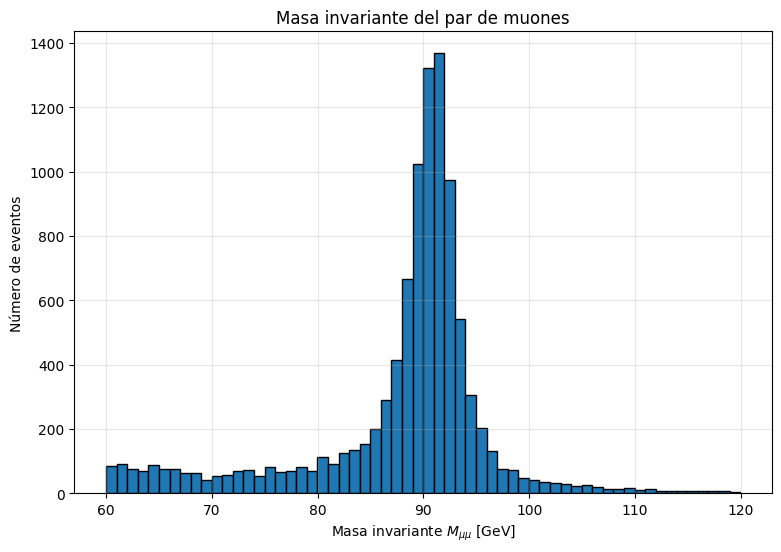

In [ ]:
#Histograma de masa
plt.figure(figsize=(9,6))

plt.hist(
    df["M_mumu"],
    bins=60,
    edgecolor="black"
)

plt.xlabel(r"Masa invariante $M_{\mu\mu}$ [GeV]")
plt.ylabel("Número de eventos")
plt.title("Masa invariante del par de muones")

plt.grid(alpha=0.3)
plt.show()